# Feature-importance report — end to end, one schema in, one folder out

**Set the parameters, Run All, get a folder.** This is the operational notebook of
the package: it reads a `unified_schema_*`, joins the pools, ranks every feature,
optionally computes the bar and the holdout, and writes a **self-describing report
directory** — tables as CSV, figures as PNG, and a `metadata.json` recording
everything needed to reproduce the run and to know what it may be compared against.

The three study notebooks answer *what did we learn*. This one answers *run it and
give me the artefacts*.

| notebook | for |
|---|---|
| [study_1__vcb_unwindowed.ipynb](study_1__vcb_unwindowed.ipynb) | the un-windowed baseline, `d=1` |
| [study_2__vcb_windowed.ipynb](study_2__vcb_windowed.ipynb) | the sequence-model setup, `d=20` |
| [study_3__null_and_holdout.ipynb](study_3__null_and_holdout.ipynb) | whether either result is real (it is not — CONTEXT §6b-6d) |
| [study_4__cross_sectional.ipynb](study_4__cross_sectional.ipynb) | the cross-section, which is (CONTEXT §9) |
| **this one** | **produce and archive a run** |

## ⚠️ Read before quoting anything this writes

**A ranking without a null is descriptive, not evidence.** `RUN_NULL = False` makes
this notebook finish in a minute and produces a `metadata.json` whose `null` field
is `null` and a `README.md` that says so in bold. That is deliberate: CONTEXT §6b
found a positive out-of-sample IC on **shuffled labels**, so `IC > 0` is not a
result. Set `RUN_NULL = True` before the numbers leave your machine.

**A bar belongs to one configuration.** `zscore` moved its own bar 43 % without
touching the data (§6c). Changing the target, the representation, the lookback or
the universe invalidates the previous null — which is why `compare_reports()` puts
those columns beside the IC, so incomparability is visible before the number is.

## Imports

In [120]:
import os
import sys

sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
from IPython.display import Image, Markdown, display

from feature_selection import evaluation, plots, report, windows
from feature_selection.selector import FeatureSelector
from feature_selection.unified_reader import UnifiedSchemaReader

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
plots.use_theme()

## Parameters — the whole run is configured here

Everything below this cell is mechanical. ⚠️ Each knob that changes an ANSWER is
recorded into `metadata.json`, so a report is never a bare table of feature names.

In [121]:
TICKER = "VCB"  # the schema is unified_schema_<ticker>
POOLS = ["pool__basic", "pool__economy_united_kingdom", "pool__targets"]
TARGET = "return_5day"
OTHER_TARGETS = ["return_10day", "return_rel_5day", "return_rel_10day"]

LOOKBACK = 20  # d — window length in sessions; 1 = un-windowed
HORIZON = 5  # h — must match the target's own horizon
NORMALIZE = "none"  # "none" | "zscore" | "window_relative"
MAX_FEATURES = None  # None = the per-run MEASURED cut (selection_cut, STL-1).
# A number here re-imposes a flat cap, which is almost never what you want: 12
# was chosen for a 27-channel pool and then applied to a 1,458-channel one.
CORR_THRESHOLD = 0.9
N_SPLITS, MIN_TRAIN = 5, 500
DEVICE = "cpu"  # ⚠️ part of the setup — see CONTEXT §5
RANDOM_STATE = 42

RUN_STABILITY = True  # per-fold SHAP ranking (cheap)
RUN_NULL = False  # ⚠️ the BAR. Slow. See the warning above.
N_NULL = 20
RUN_HOLDOUT = False  # score an untouched tail once, with a control
HOLDOUT_START = "2024-06-01"

TOP_N_FIGURES = 30
NOTES = ""  # free text, lands in metadata.json and README.md

# ⚠️ Identity and taxonomy columns are never candidates. On a single-ticker panel
# they are constant and would be dropped anyway; naming them keeps that a decision
# rather than an accident, and keeps this cell correct for a multi-ticker panel.
IDENTITY = [
    "exchange",
    "ticker",
    "sector",
    "sector_code",
    "industry_group",
    "industry_group_code",
    "industry",
    "industry_code",
    "sub_industry",
    "sub_industry_code",
]

## 1. Read and join

`UnifiedSchemaReader` types every column from `information_schema` rather than
guessing — psycopg2 returns `numeric` as `Decimal`, which pandas stores as dtype
`object`, so `close_adjust` would otherwise arrive looking like a string column.

⚠️ **`join_log` records which keys each merge actually used** and goes into the
report. Every pool is keyed `(date, exchange, ticker)` as of 2026-08-04, but the
join intersects per pair rather than assuming, so a pool that predates the change
joins correctly instead of silently wrongly.

In [122]:
reader = UnifiedSchemaReader(TICKER).connect()
overview = reader.overview()
panel = reader.join(POOLS)
join_log = reader.join_log
schema_name, database = reader.schema, reader.database
reader.close()

print(
    f"{schema_name}: {panel.shape[0]:,} rows x {panel.shape[1]} columns "
    f"({panel['date'].min():%Y-%m-%d} -> {panel['date'].max():%Y-%m-%d})"
)
overview

unified_schema_vcb: 4,235 rows x 224 columns (2009-06-30 -> 2026-06-25)


,table,rows,columns,key_columns,first_date,last_date
0,pool__basic,4235,38,"date, exchange, ticker",2009-06-30,2026-06-25
1,pool__economy_australia,4235,183,"date, exchange, ticker",2009-06-30,2026-06-25
2,pool__economy_european_union,4235,129,"date, exchange, ticker",2009-06-30,2026-06-25
3,pool__economy_germany,4235,180,"date, exchange, ticker",2009-06-30,2026-06-25
4,pool__economy_hong_kong_china,4235,95,"date, exchange, ticker",2009-06-30,2026-06-25
5,pool__economy_india,4235,124,"date, exchange, ticker",2009-06-30,2026-06-25
6,pool__economy_indonesia,4235,108,"date, exchange, ticker",2009-06-30,2026-06-25
7,pool__economy_japan,4235,184,"date, exchange, ticker",2009-06-30,2026-06-25
8,pool__economy_mainland_china,4235,167,"date, exchange, ticker",2009-06-30,2026-06-25
9,pool__economy_malaysia,4235,113,"date, exchange, ticker",2009-06-30,2026-06-25


In [123]:
pd.DataFrame(join_log)

,table,join_keys,how,rows_before,rows_after,columns_added,duplicate_columns_dropped
0,pool__economy_united_kingdom,"date, exchange, ticker",inner,4235,4235,182,
1,pool__targets,"date, exchange, ticker",inner,4235,4235,4,


### The target's own arithmetic

In [124]:
labels = pd.DataFrame(
    [
        {
            "target": column,
            "labelled": int(panel[column].notna().sum()),
            "unlabelled_tail": int(panel[column].isna().sum()),
            "mean": round(float(panel[column].mean()), 6),
            "sd": round(float(panel[column].std()), 6),
        }
        for column in [TARGET] + [c for c in OTHER_TARGETS if c in panel.columns]
    ]
)
labels

,target,labelled,unlabelled_tail,mean,sd
0,return_5day,4230,5,0.003190,0.042946
1,return_10day,4225,10,0.006458,0.059825
2,return_rel_5day,4228,7,0.001052,0.032045
3,return_rel_10day,4223,12,0.002170,0.043826


## 2. Run the selection

Six rankers → rank-average ensemble → correlation prune at channel level → purged
walk-forward. ⚠️ The purge gap is `d + h - 1`, not `h` (CONTEXT §1a).

In [125]:
selector = FeatureSelector(
    panel=panel,
    target=TARGET,
    exclude=IDENTITY + [c for c in OTHER_TARGETS if c != TARGET],
    max_features=MAX_FEATURES,
    corr_threshold=CORR_THRESHOLD,
    horizon=HORIZON,
    lookback=LOOKBACK,
    window_stats=windows.WINDOW_STATS,
    normalize=NORMALIZE,
    n_splits=N_SPLITS,
    min_train=MIN_TRAIN,
    device=DEVICE,
    random_state=RANDOM_STATE,
    holdout_start=HOLDOUT_START if RUN_HOLDOUT else None,
)

result = selector.run(stability=RUN_STABILITY)
result.setup.to_frame().T

,target,horizon_h,lookback_d,normalize,purge_gap_rows,window_stats,dropped_by_normalize,dev_samples,holdout_start,holdout_rows,purged_at_boundary,channels,design_columns,kept,device
setup,return_5day,5,20,none,24,"last, mean, slope, sd, min, max",1,4211,—,0,0,207,1241,12,cpu


### The ranking — this is the deliverable

In [126]:
result.ranking.round(3)

,ensemble,kept,dropped_for,spearman,mutual_info,xgb_gain,xgb_shap,lasso,permutation
united_kingdom__economy__government__economics__gbtaxr,20.667,True,,0.407,0.719,0.473,0.202,0.0,0.101
united_kingdom__economy__housing__economics__gbmr,21.000,True,,0.244,0.646,0.488,0.436,0.0,0.298
united_kingdom__economy__gdp__economics__gbgdpmin,35.500,True,,0.214,0.674,0.659,0.114,0.0,0.081
united_kingdom__economy__trade__economics__gbed,37.667,True,,0.170,0.664,0.277,0.373,0.0,0.216
united_kingdom__economy__labor__economics__gbreeb,37.833,True,,0.281,0.568,0.327,0.488,0.0,0.093
...,...,...,...,...,...,...,...,...,...
united_kingdom__economy__taxes__economics__gbssr,135.167,False,,0.139,0.275,0.000,0.000,0.0,0.000
united_kingdom__economy__labor__economics__gbraw,138.000,False,,0.107,0.407,0.000,0.000,0.0,0.000
united_kingdom__economy__money__economics__gbdir,145.000,False,,0.062,0.368,0.000,0.000,0.0,0.000
united_kingdom__economy__taxes__economics__gbssre,150.333,False,,0.031,0.269,0.000,0.000,0.0,0.000


In [127]:
print("kept:", result.kept)
print("\ndropped as redundant:")
display(pd.Series(result.dropped_correlated, name="duplicated").to_frame())
if result.dead_methods:
    print(f"\n⚠️ dead methods (separated nothing): {result.dead_methods}")

kept: ['united_kingdom__economy__government__economics__gbtaxr', 'united_kingdom__economy__housing__economics__gbmr', 'united_kingdom__economy__gdp__economics__gbgdpmin', 'united_kingdom__economy__trade__economics__gbed', 'united_kingdom__economy__labor__economics__gbreeb', 'united_kingdom__economy__business__economics__gbcap', 'united_kingdom__economy__prices__economics__gbppimm', 'united_kingdom__economy__housing__economics__gbhpiyy', 'united_kingdom__economy__money__economics__gboiar', 'united_kingdom__economy__prices__economics__gbei', 'close_adjust', 'foreign_own']

dropped as redundant:


,duplicated


### Walk-forward — the only numbers carrying a generalisation claim

In [128]:
display(result.validation.round(4))
evaluation.ic_summary(result.validation, HORIZON).to_frame().T.round(4)

,fold,feature_set,n_channels,n_columns,n_train,n_test,n_eff_test,ic,r2,hit_rate
0,fold 1,all channels,207,1241,500,737,147.4,0.0808,-0.2752,0.5156
1,fold 1,selected,12,72,500,737,147.4,0.1070,-0.6532,0.5020
2,fold 2,all channels,207,1241,1237,737,147.4,0.0386,-1.4738,0.4776
3,fold 2,selected,12,72,1237,737,147.4,0.0157,-1.7780,0.4708
4,fold 3,all channels,207,1241,1974,737,147.4,0.0417,-0.5534,0.4355
5,fold 3,selected,12,72,1974,737,147.4,0.0075,-1.6868,0.4206
6,fold 4,all channels,207,1241,2711,737,147.4,-0.0049,-0.2862,0.5142
7,fold 4,selected,12,72,2711,737,147.4,0.0187,-1.2967,0.4830
8,fold 5,all channels,207,1241,3448,739,147.8,0.0625,-0.6030,0.4384
9,fold 5,selected,12,72,3448,739,147.8,0.1836,-0.1184,0.5575


,folds,ic_mean,ic_trend_per_fold,ic_min,ic_max,ic_fold_sd,hit_rate,n_test_rows,n_eff_per_fold,se_ic_per_fold
selected,5.0,0.0665,0.0156,0.0075,0.1836,0.077,0.4868,737.0,147.4,0.0826


## 3. The bar, and the holdout

⚠️ Both are optional and both are OFF by default, because both are slow — and both
are what turn a ranking into evidence. A report written without them says so.

In [129]:
null = None
if RUN_NULL:

    def factory(frame):
        clone = FeatureSelector(
            panel=frame,
            target=TARGET,
            exclude=IDENTITY + [c for c in OTHER_TARGETS if c != TARGET],
            max_features=MAX_FEATURES,
            corr_threshold=CORR_THRESHOLD,
            horizon=HORIZON,
            lookback=LOOKBACK,
            normalize=NORMALIZE,
            n_splits=N_SPLITS,
            min_train=MIN_TRAIN,
            device=DEVICE,
            random_state=RANDOM_STATE,
        )
        return clone.run(stability=False)

    observed = evaluation.ic_summary(result.validation, HORIZON)["ic_mean"]
    null = evaluation.null_distribution(
        panel=panel,
        target=TARGET,
        factory=factory,
        observed=observed,
        horizon=HORIZON,
        lookback=LOOKBACK,
        n_draws=N_NULL,
        seed=7,
        label=f"{schema_name} / {TARGET}",
    )
    display(null.summary().to_frame().T)
else:
    print("⚠️ RUN_NULL is False — this report will record that no bar was computed.")

⚠️ RUN_NULL is False — this report will record that no bar was computed.


In [130]:
holdout = selector.score_holdout(result) if RUN_HOLDOUT else None
if holdout is not None:
    display(holdout.round(4))

## 4. Write the report

One folder: `metadata.json`, `README.md`, the CSVs and `figures/*.png`.

In [131]:
written = report.write_report(
    result,
    selector=selector,
    panel=panel,
    schema=schema_name,
    tables=POOLS,
    database=database,
    join_log=join_log,
    null=null,
    holdout=holdout,
    notes=NOTES,
    top=TOP_N_FIGURES,
)
written.summary().to_frame().T

,run_id,schema,tables,target,rows,channels,kept,ic_mean,ic_trend,hit_rate,null_bar,clears_null,files,path
report,2026-08-08__unified_schema_vcb__return_5day__1...,unified_schema_vcb,"pool__basic, pool__economy_united_kingdom, poo...",return_5day,4235,207,12,0.066495,0.015613,0.486807,None,None,18,d:\GIT\master-thesis\reports\feature_selection...


In [132]:
print(written.path)
for artefact in written.metadata["artifacts"]:
    print(f"  {artefact['bytes']:>9,}  {artefact['file']}")

d:\GIT\master-thesis\reports\feature_selection\2026-08-08__unified_schema_vcb__return_5day__103654
     44,376  feature_importance.csv
    161,525  design_scores.csv
      1,087  validation.csv
     14,094  target_correlation.csv
    864,208  channel_correlation.csv
     15,443  stability.csv
     11,726  coverage.csv
    272,661  figures/01_ensemble_ranking.png
    406,961  figures/02_method_heatmap.png
    245,991  figures/03_target_correlation.png
    563,594  figures/04_channel_correlation.png
    260,384  figures/05_stat_profile.png
     42,733  figures/06_validation.png
    320,636  figures/07_stability.png
    495,236  figures/08_coverage.png
     40,891  figures/09_target_distribution.png


### The README the run wrote about itself

In [133]:
display(
    Markdown(open(os.path.join(written.path, "README.md"), encoding="utf-8").read())
)

# Feature-importance run — `return_5day`

*Generated 2026-08-08T03:36:57.926401+00:00 at commit `1eae672+dirty`.*

## Input

- **schema** `unified_schema_vcb` (database `database_main_v2`)
- **tables** `pool__basic`, `pool__economy_united_kingdom`, `pool__targets`
- **panel** 4,235 rows x 224 columns
- **range** 2009-06-30 to 2026-06-25 (4235 sessions, 1 tickers)

## Target

- **`return_5day`** — forward 5-session return on close_adjust
- horizon **5** sessions; 4,230 labelled, 5 unlabelled
- mean +0.00319, sd 0.04295, range -0.1876 to +0.2914

## Setup

| knob | value |
|---|---|
| `selector_class` | FeatureSelector |
| `lookback_d` | 20 |
| `horizon_h` | 5 |
| `normalize` | none |
| `purge_gap_rows` | 24 |
| `window_stats` | last, mean, slope, sd, min, max |
| `n_splits` | 5 |
| `min_train` | 500 |
| `max_features` | 12 |
| `corr_threshold` | 0.9 |
| `device` | cpu |
| `random_state` | 42 |
| `permutation_repeats` | 10 |
| `holdout_start` | — |
| `dev_samples` | 4211 |
| `design_columns` | 1241 |

## Result

- **12 of 207 channels kept** after the |rho| >= 0.9 redundancy prune
- **top 10 by ensemble rank**: `united_kingdom__economy__government__economics__gbtaxr`, `united_kingdom__economy__housing__economics__gbmr`, `united_kingdom__economy__gdp__economics__gbgdpmin`, `united_kingdom__economy__trade__economics__gbed`, `united_kingdom__economy__labor__economics__gbreeb`, `united_kingdom__economy__business__economics__gbcap`, `united_kingdom__economy__prices__economics__gbppimm`, `united_kingdom__economy__housing__economics__gbhpiyy`, `united_kingdom__economy__money__economics__gboiar`, `united_kingdom__economy__prices__economics__gbei`

| metric | selected | all channels |
|---|---|---|
| `ic_mean` | +0.0665 | +0.0437 |
| `ic_trend_per_fold` | +0.0156 | -0.0080 |
| `hit_rate` | +0.4868 | +0.4763 |
| `n_eff_per_fold` | 147.4 | 147.4 |

## The bar

- ⚠️ **NO NULL WAS COMPUTED FOR THIS RUN.** A positive IC is not a result on its own — see `CONTEXT.md` §6b and §8. Treat the ranking below as descriptive until a shuffled-label null has been run for *this* configuration.

## Files

- `feature_importance.csv`
- `design_scores.csv`
- `validation.csv`
- `target_correlation.csv`
- `channel_correlation.csv`
- `stability.csv`
- `coverage.csv`
- `figures/01_ensemble_ranking.png`
- `figures/02_method_heatmap.png`
- `figures/03_target_correlation.png`
- `figures/04_channel_correlation.png`
- `figures/05_stat_profile.png`
- `figures/06_validation.png`
- `figures/07_stability.png`
- `figures/08_coverage.png`
- `figures/09_target_distribution.png`
- `metadata.json`


### The figures

01_ensemble_ranking.png


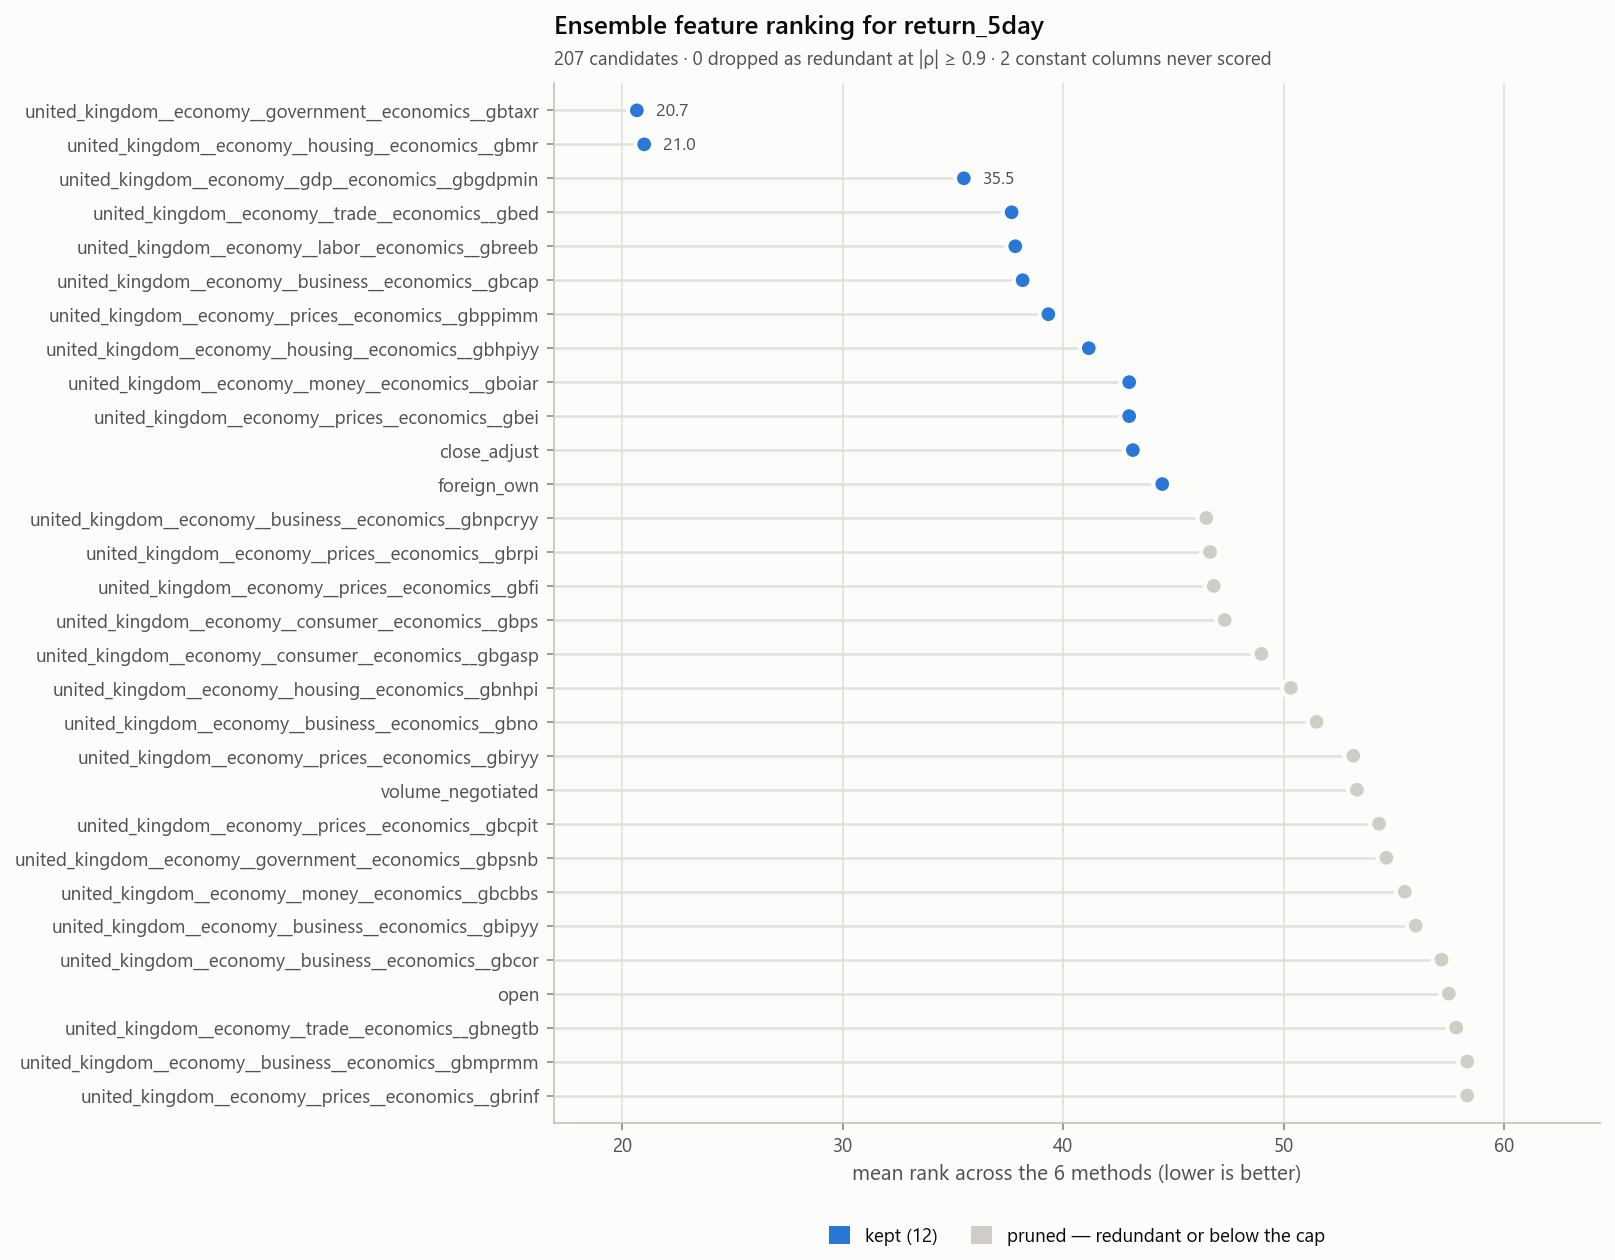

02_method_heatmap.png


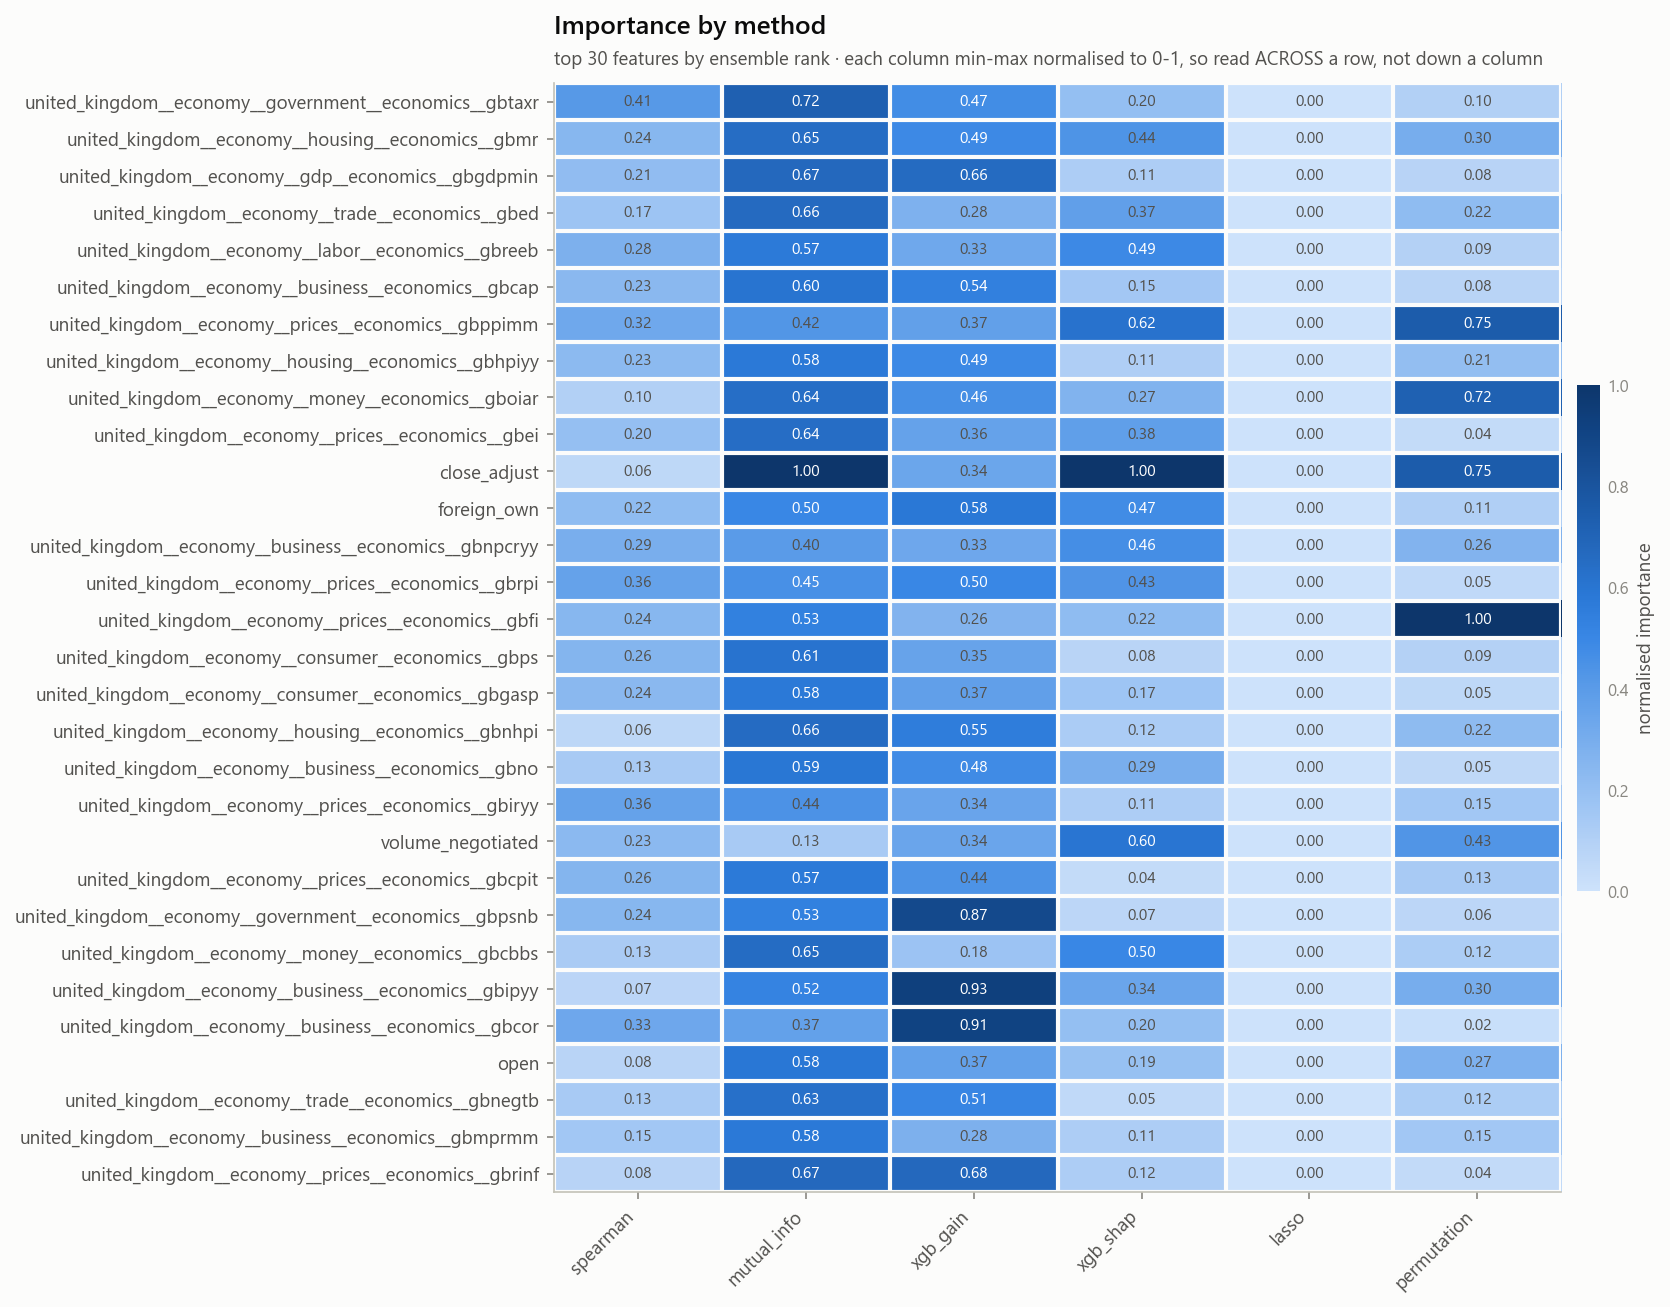

03_target_correlation.png


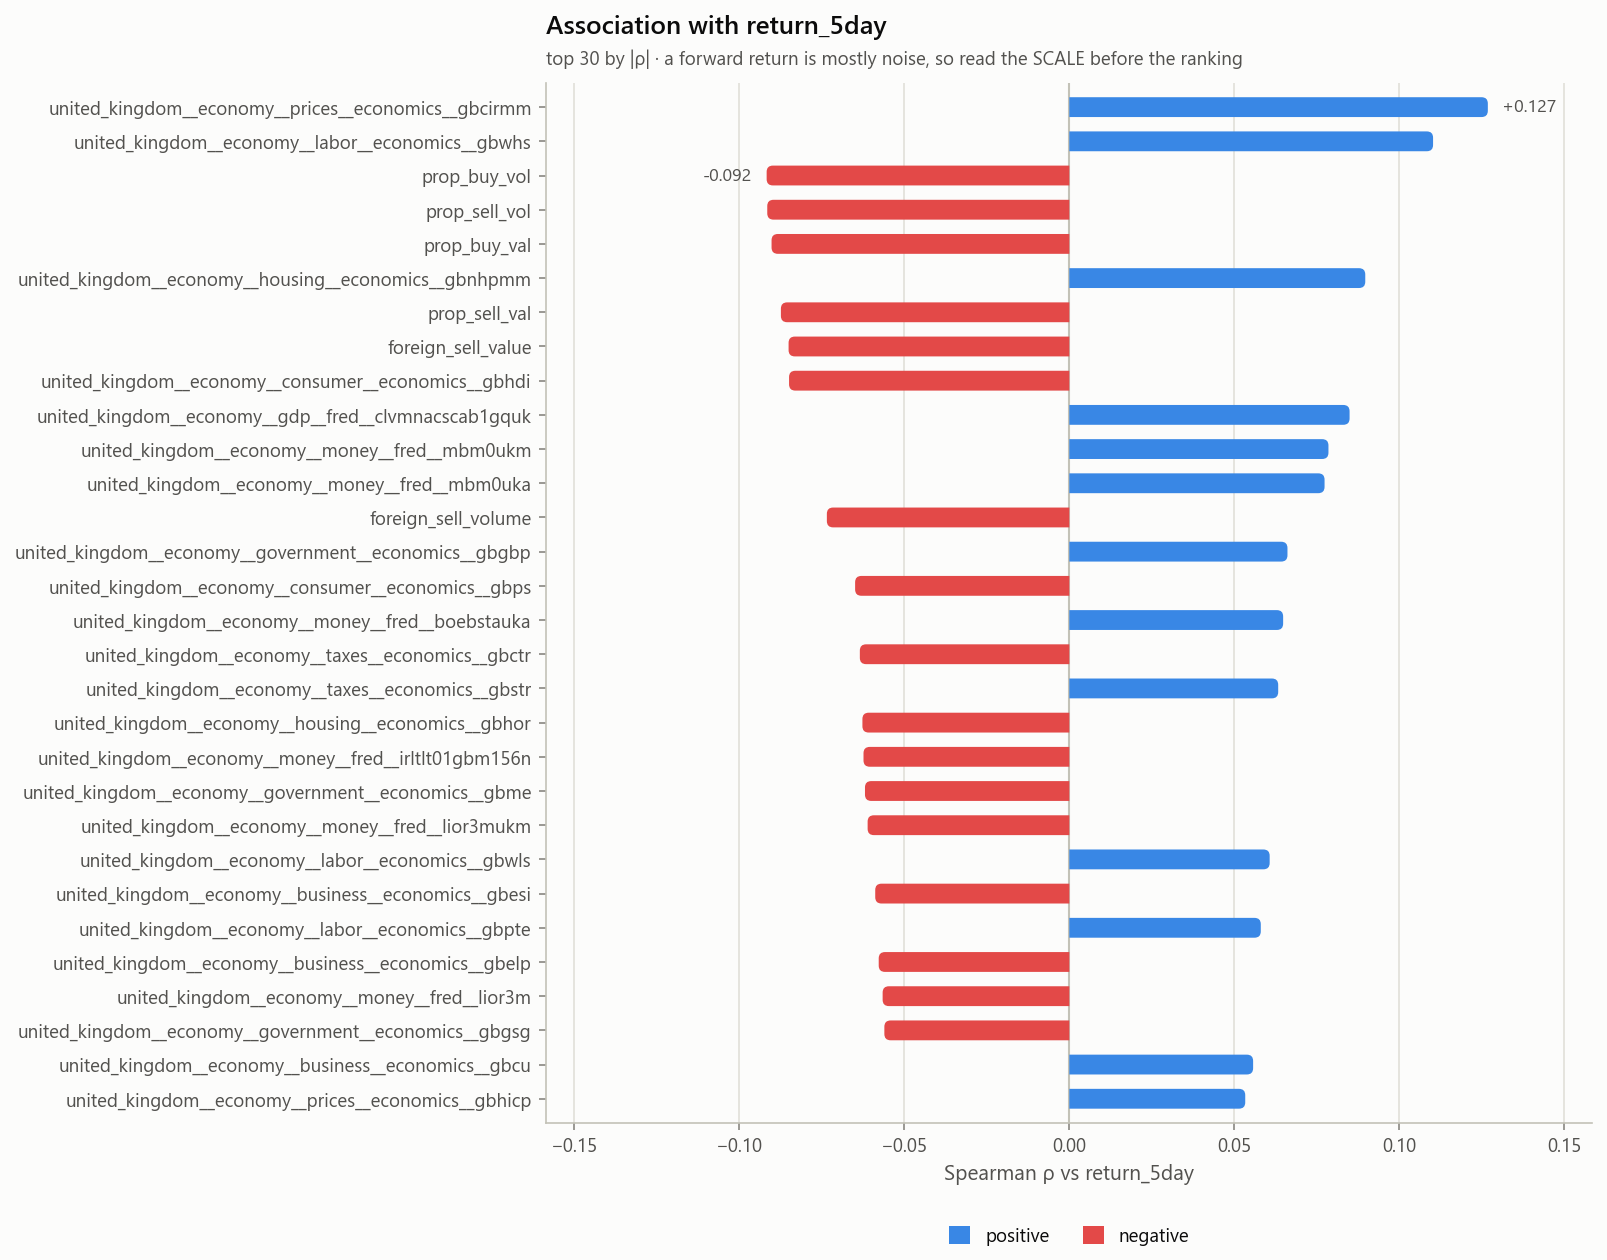

04_channel_correlation.png


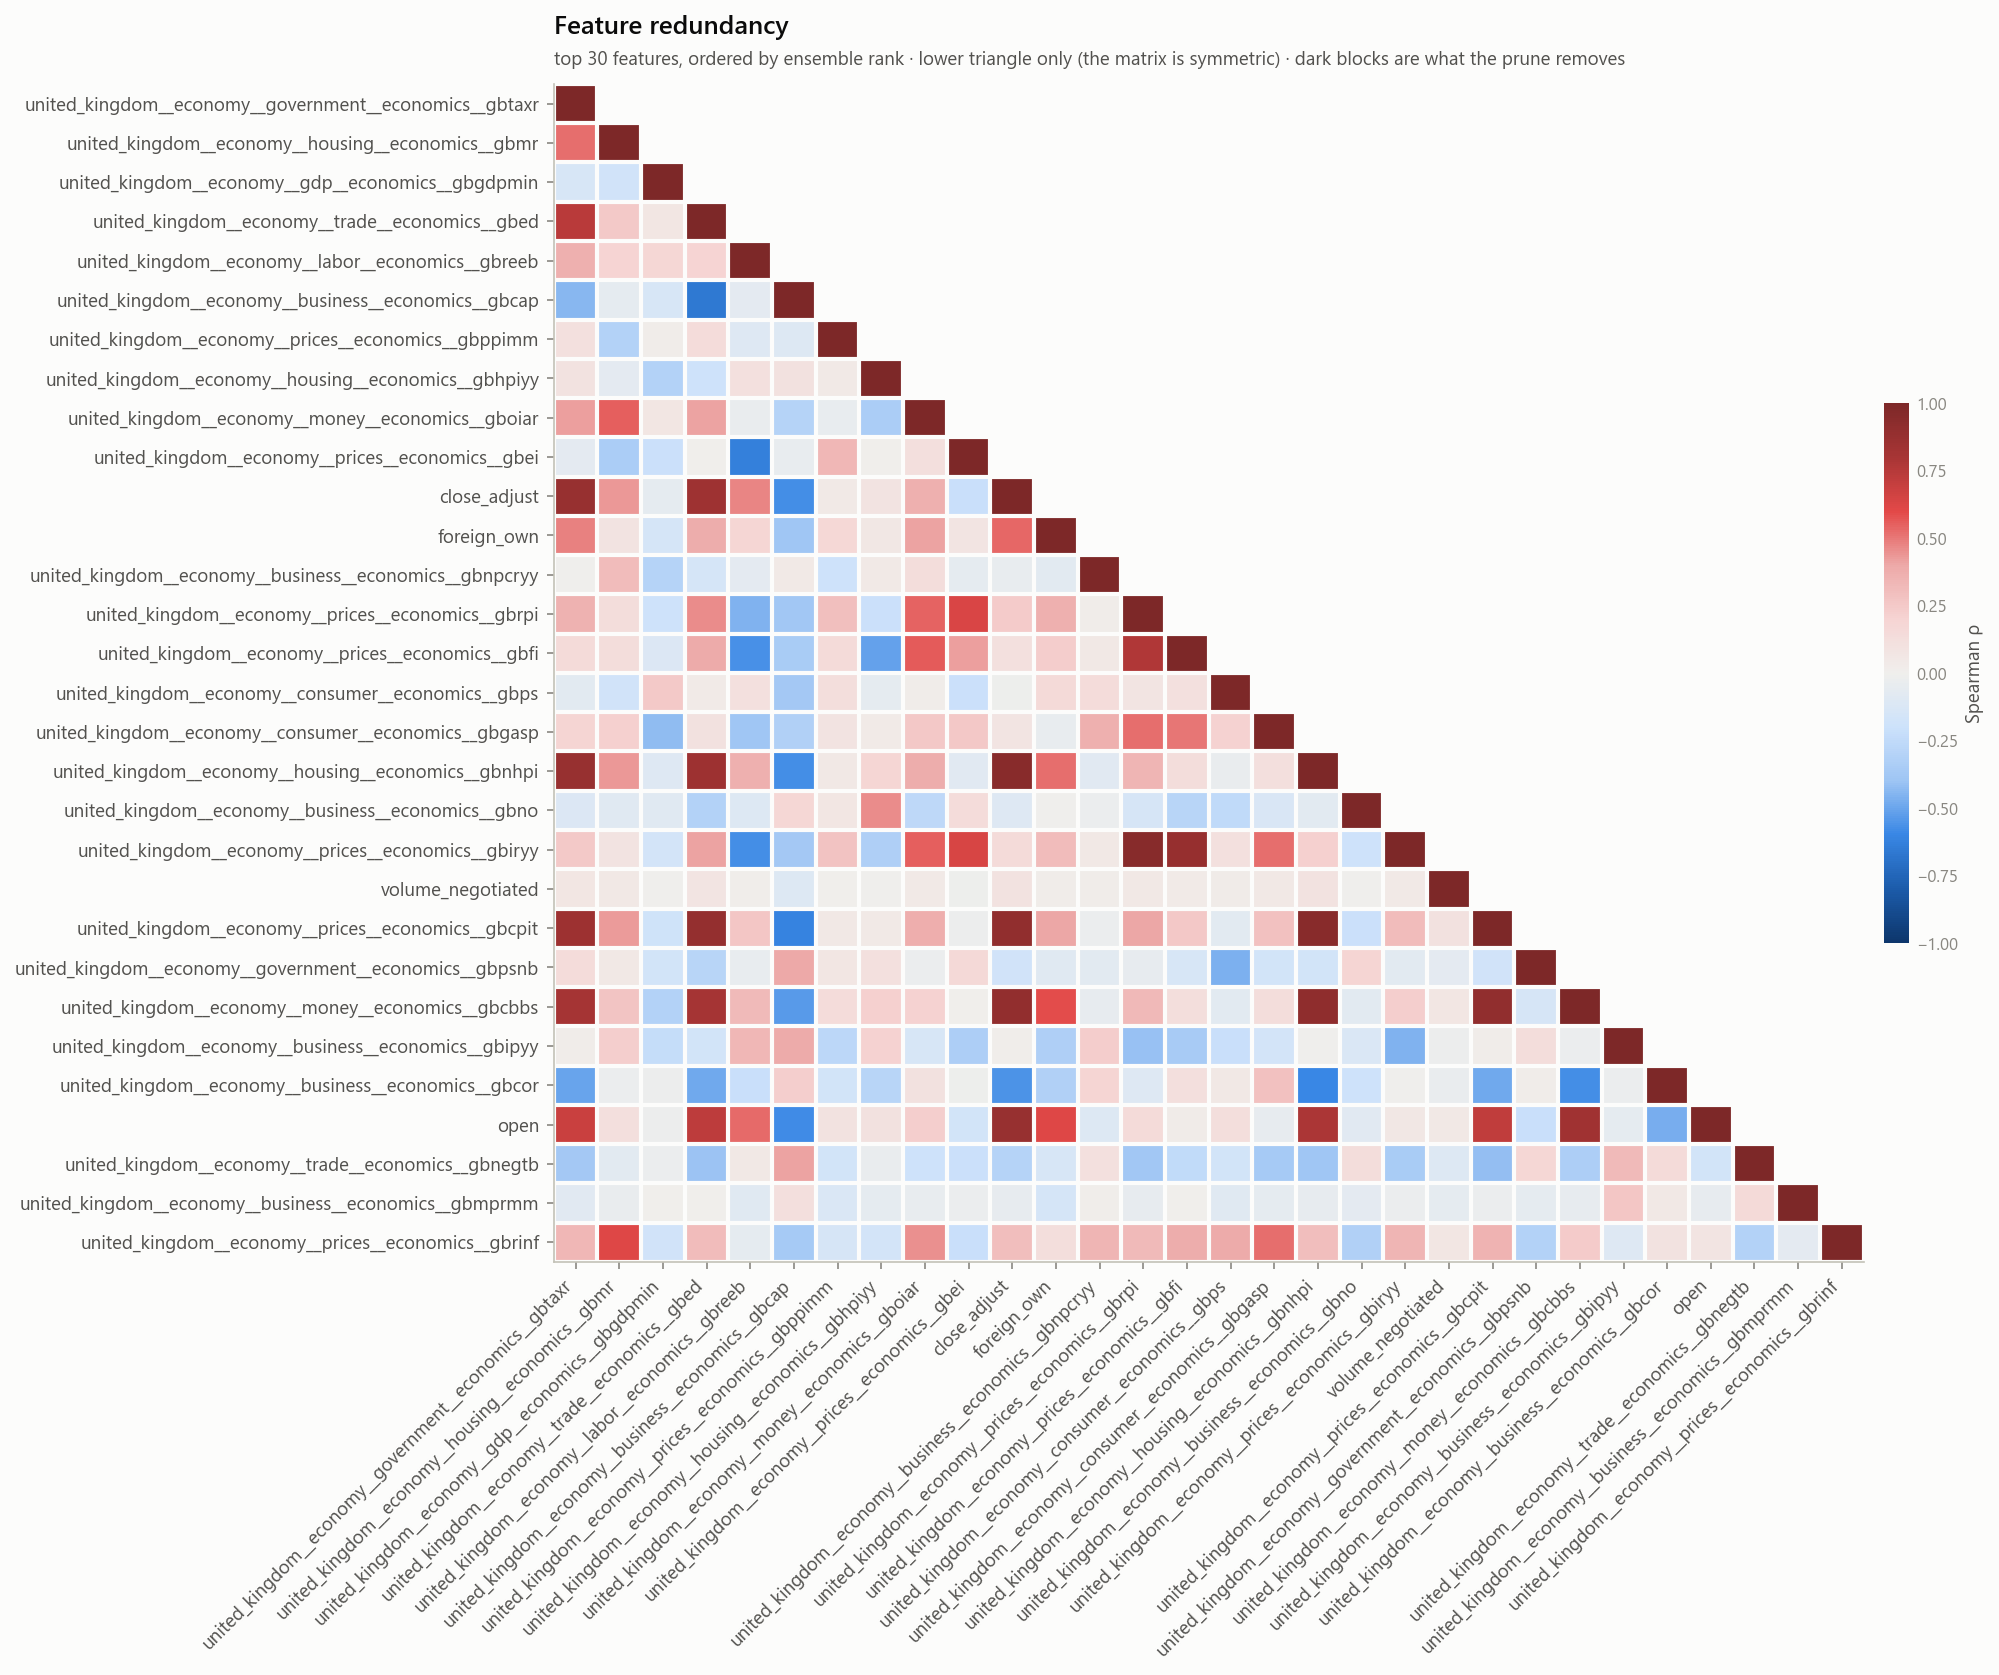

05_stat_profile.png


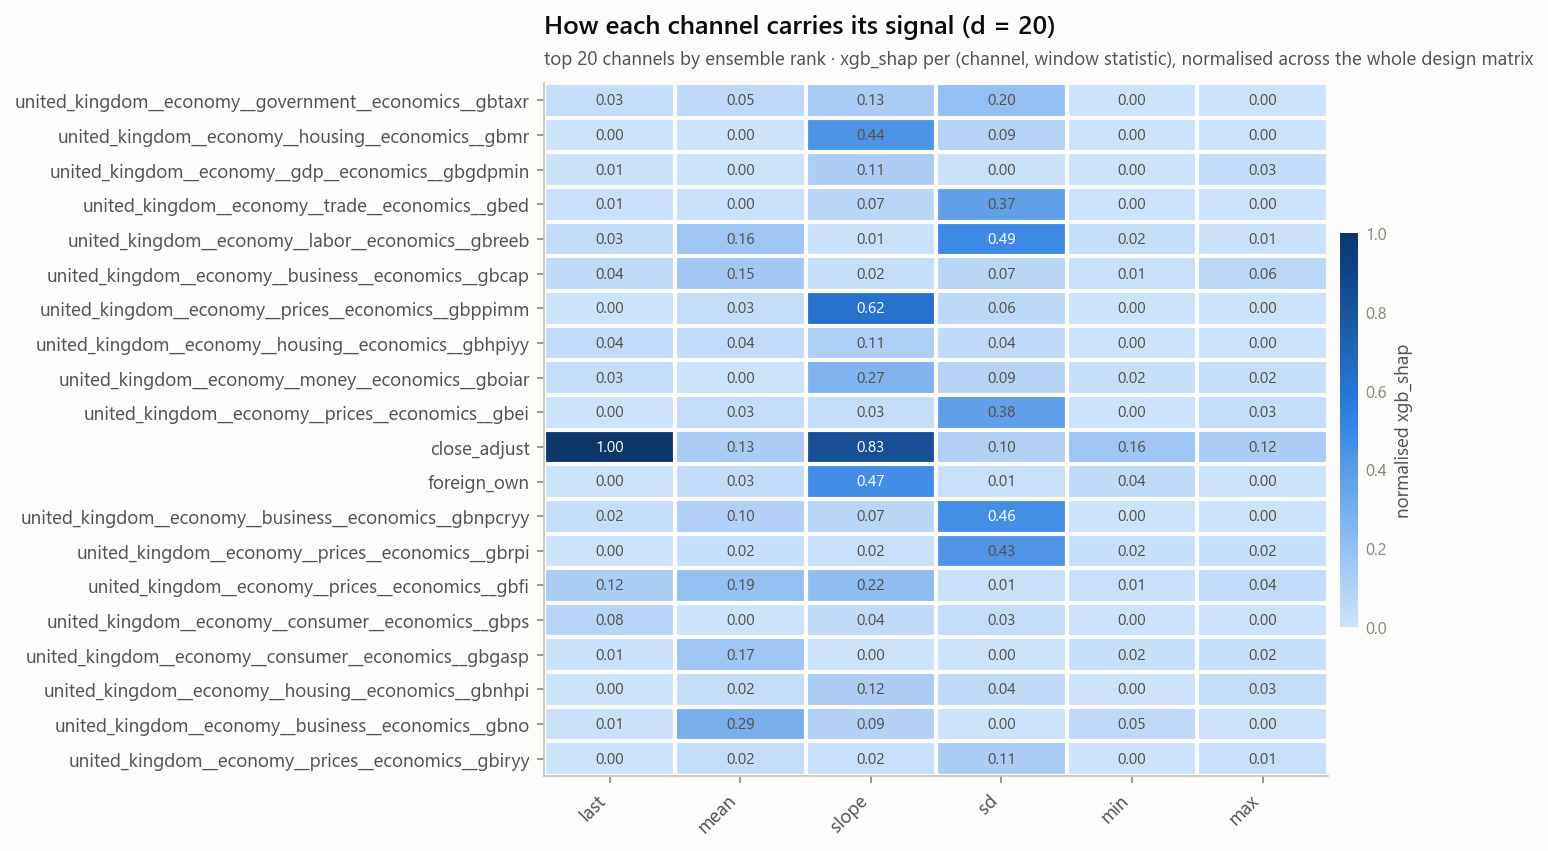

06_validation.png


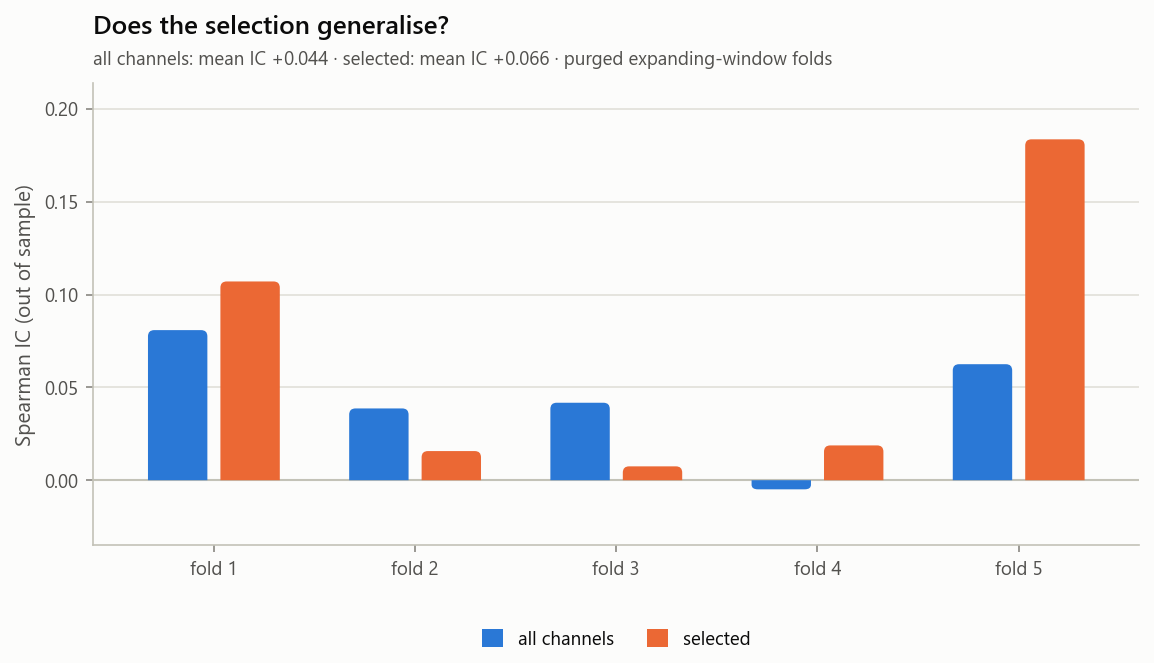

07_stability.png


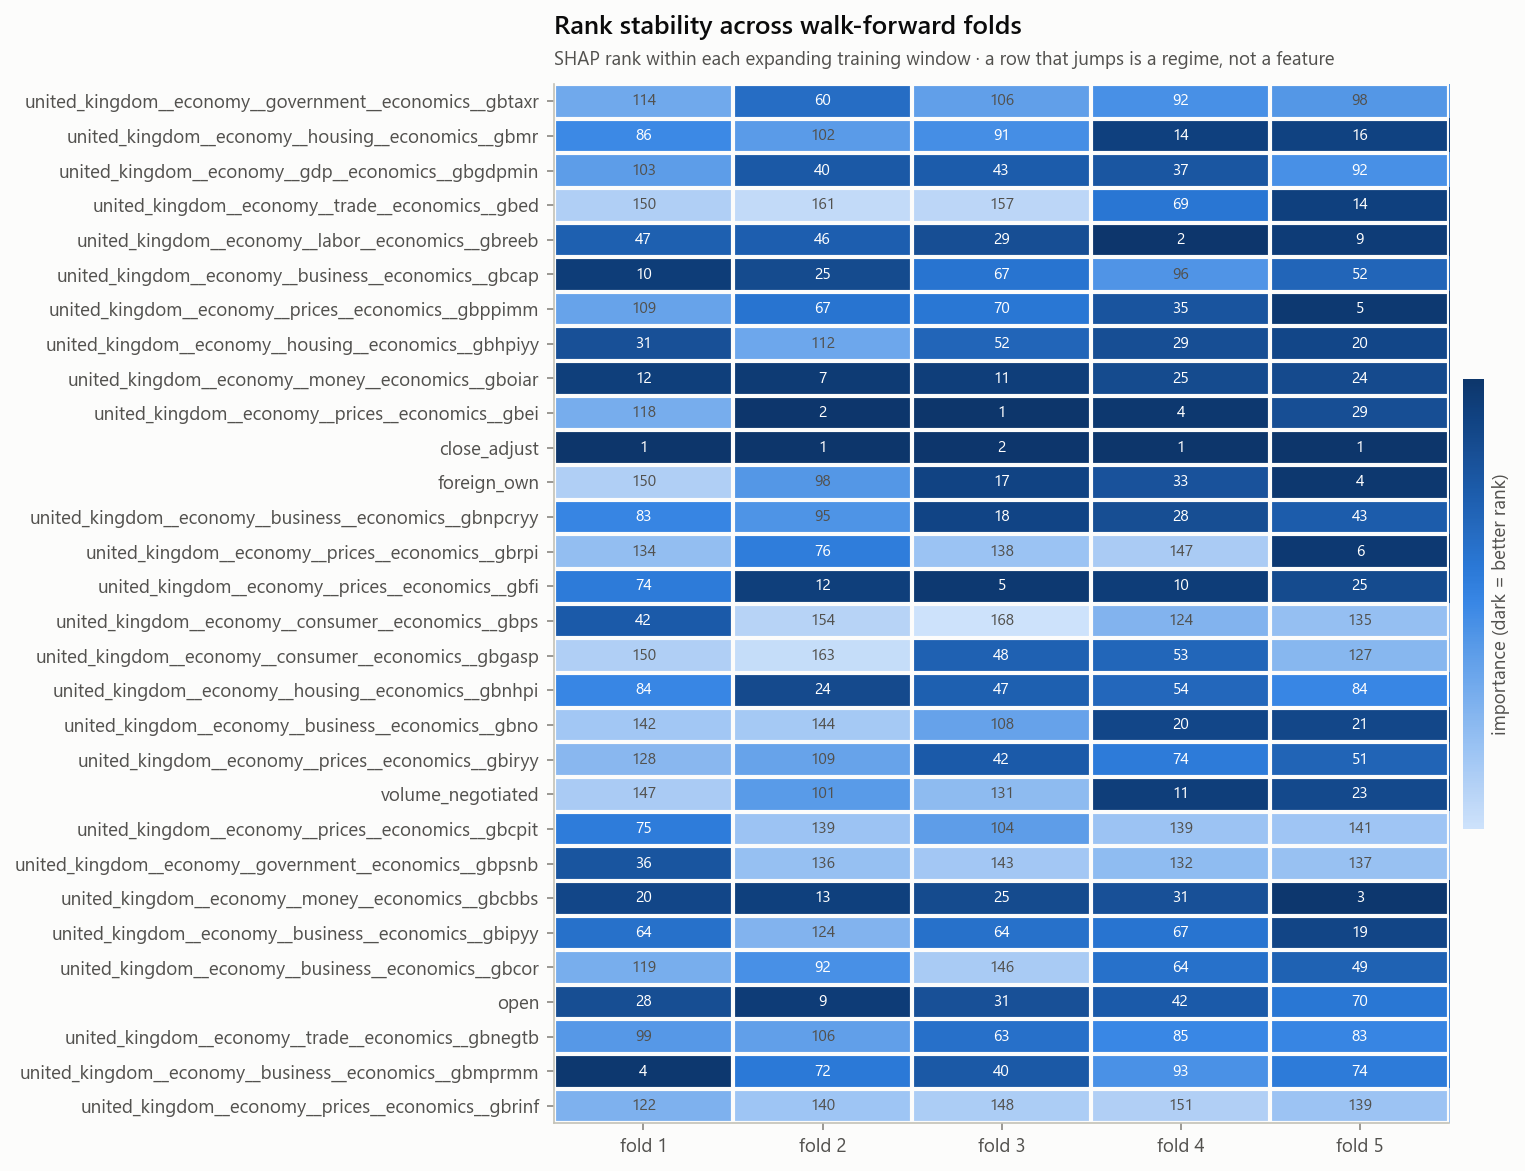

08_coverage.png


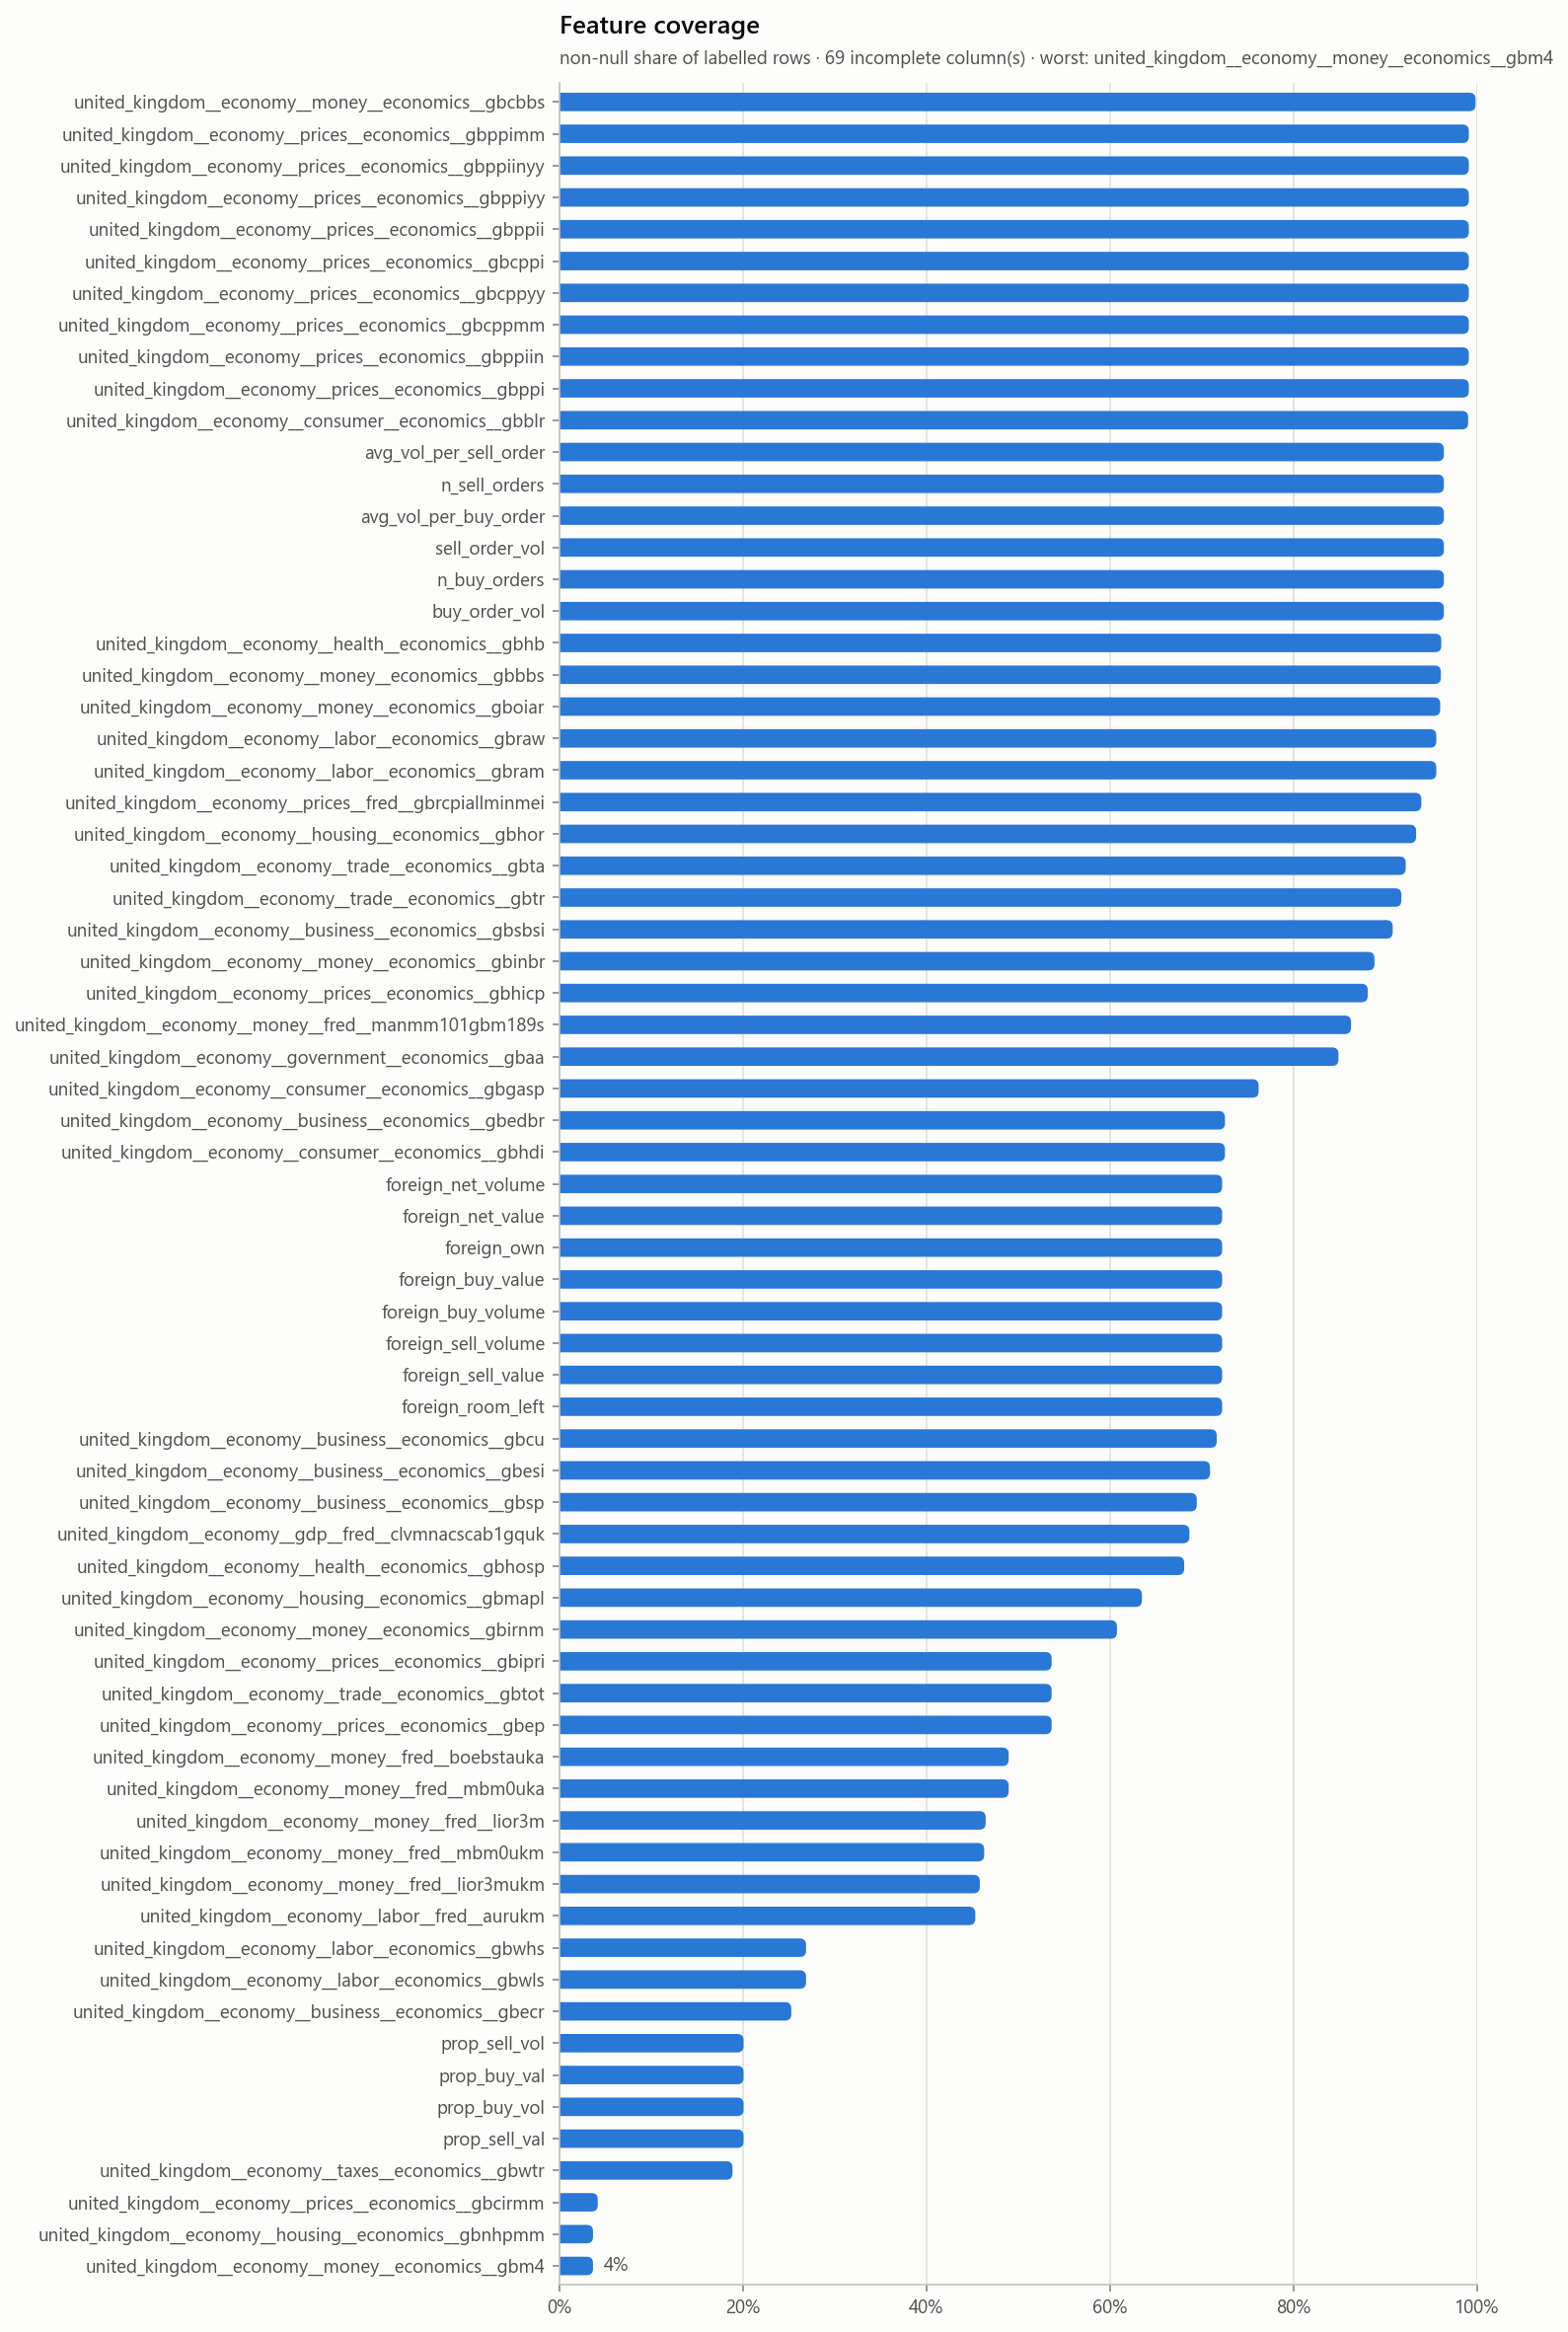

09_target_distribution.png


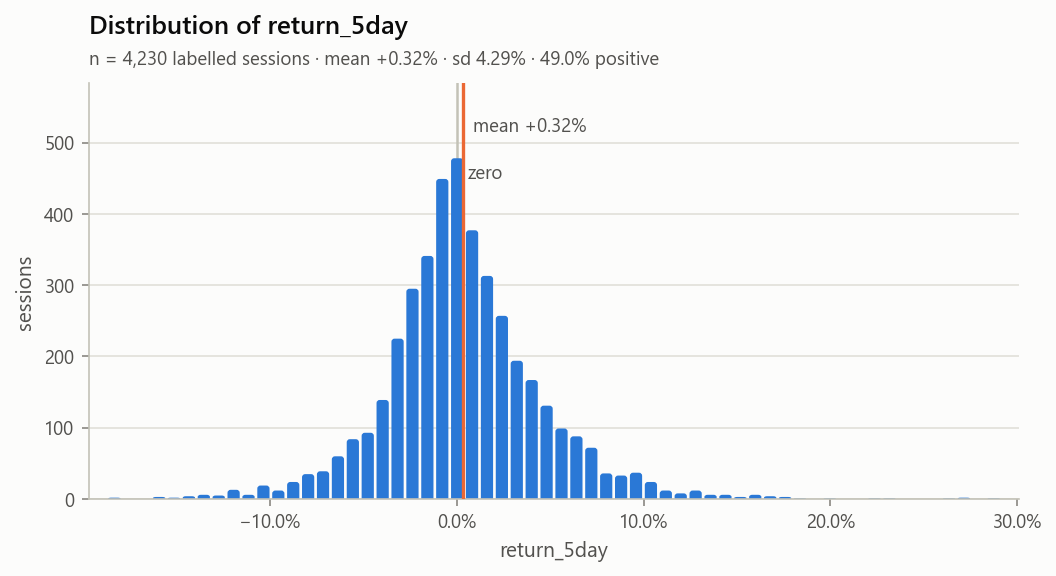

In [134]:
for figure in written.figures:
    print(os.path.basename(figure))
    display(Image(filename=figure, width=760))

### The feature-importance CSV, read back

In [135]:
pd.read_csv(written.importance_csv, index_col="channel").round(3)

,rank,ensemble,kept,dropped_for,spearman,mutual_info,xgb_gain,xgb_shap,lasso,permutation,spearman_vs_target,best_stat__spearman,best_stat__mutual_info,best_stat__xgb_gain,best_stat__xgb_shap,best_stat__lasso,best_stat__permutation
channel,,,,,,,,,,,,,,,,,
united_kingdom__economy__government__economics__gbtaxr,1,20.667,True,NaN,0.407,0.719,0.473,0.202,0.0,0.101,-0.004,sd,min,last,sd,last,slope
united_kingdom__economy__housing__economics__gbmr,2,21.000,True,NaN,0.244,0.646,0.488,0.436,0.0,0.298,0.028,slope,min,sd,slope,last,slope
united_kingdom__economy__gdp__economics__gbgdpmin,3,35.500,True,NaN,0.214,0.674,0.659,0.114,0.0,0.081,-0.048,max,max,max,slope,last,slope
united_kingdom__economy__trade__economics__gbed,4,37.667,True,NaN,0.170,0.664,0.277,0.373,0.0,0.216,0.011,sd,min,sd,sd,last,sd
united_kingdom__economy__labor__economics__gbreeb,5,37.833,True,NaN,0.281,0.568,0.327,0.488,0.0,0.093,0.019,sd,max,sd,sd,last,sd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
united_kingdom__economy__taxes__economics__gbssr,203,135.167,False,NaN,0.139,0.275,0.000,0.000,0.0,0.000,0.014,sd,max,last,last,last,last
united_kingdom__economy__labor__economics__gbraw,204,138.000,False,NaN,0.107,0.407,0.000,0.000,0.0,0.000,0.014,slope,mean,last,last,last,last
united_kingdom__economy__money__economics__gbdir,205,145.000,False,NaN,0.062,0.368,0.000,0.000,0.0,0.000,-0.003,slope,mean,last,last,last,last


## 5. Comparing runs

⚠️ **Built to make INCOMPARABILITY visible.** Two runs differing in `target`,
`normalize`, `lookback_d` or the universe are different experiments; their ICs must
not be set beside one another as if the difference were noise. `compare_reports`
puts those columns next to the IC so the difference is seen first.

In [136]:
root = report.DEFAULT_REPORT_ROOT
runs = [
    os.path.join(root, d)
    for d in sorted(os.listdir(root))
    if os.path.exists(os.path.join(root, d, "metadata.json"))
]
report.compare_reports(runs)

,run_id,schema,target,rows,tickers,lookback_d,horizon_h,normalize,feature_normalize,device,kept,ic_mean,hit_rate,null_bar,z_vs_null,clears_null,commit
0,2026-08-04__unified_schema_vcb__pool_fa__retur...,unified_schema_vcb,return_5day,4235,1,1,5,none,None,cpu,12,0.015662,0.467919,0.0740,-0.25,False,9ff2ac5
1,2026-08-04__unified_schema_vcb__pool_ta__retur...,unified_schema_vcb,return_5day,4235,1,1,5,none,None,cpu,12,0.112110,0.515973,0.0754,2.52,True,ba495b3
2,2026-08-04__unified_schema_vcb__return_5day__2...,unified_schema_vcb,return_5day,4235,1,20,5,none,None,cpu,12,0.063595,0.491974,NaN,NaN,None,7ab2488+dirty
3,2026-08-05__unified_schema_bank__pool_basic__c...,unified_schema_bank,cs_rank_5day,39056,20,20,5,none,cs_rank,cpu,12,0.008688,0.496594,0.0249,0.11,False,9d529dd+dirty
4,2026-08-07__unified_schema_vcb__return_5day__0...,unified_schema_vcb,return_5day,4235,1,20,5,none,None,cpu,12,0.025338,0.490920,NaN,NaN,None,1eae672+dirty
5,2026-08-07__unified_schema_vcb__return_5day__0...,unified_schema_vcb,return_5day,4235,1,20,5,none,None,cpu,12,0.144814,0.521022,NaN,NaN,None,1eae672+dirty
6,2026-08-07__unified_schema_vcb__return_5day__1...,unified_schema_vcb,return_5day,4235,1,20,5,none,None,cpu,12,0.050784,0.525643,NaN,NaN,None,1eae672+dirty
7,2026-08-07__unified_schema_vcb__return_5day__1...,unified_schema_vcb,return_5day,4235,1,20,5,none,None,cpu,12,0.081994,0.480033,NaN,NaN,None,1eae672+dirty
8,2026-08-07__unified_schema_vcb__return_5day__1...,unified_schema_vcb,return_5day,4235,1,20,5,none,None,cpu,12,0.059157,0.479275,NaN,NaN,None,1eae672+dirty
9,2026-08-07__unified_schema_vcb__return_5day__1...,unified_schema_vcb,return_5day,4235,1,20,5,none,None,cpu,12,0.066157,0.502056,NaN,NaN,None,1eae672+dirty
